*Section 1 Data Collection*

In [14]:
# Cell 1: Imports
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Ensure graphs render inside the notebook
%matplotlib inline

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


*Section 2 Data Pre-Processing*

In [15]:
# Cell 2: Data Loading and Preprocessing
base_dir = r"C:\Users\mthar\Documents\Materi Kuliah - Copy\IPB\Semester 6\Visual Komputer Cerdas\katakanamodel3"

print("Loading .npz dataset...")
# Load the compressed npz file
data = np.load(os.path.join(base_dir, 'etl1_katakana.npz'))
x_data = data['images']
y_data = data['labels']

# Load the class mapping for our graphs later
with open(os.path.join(base_dir, 'etl1_class_mapping.json'), 'r') as f:
    idx_to_romaji = json.load(f)

num_classes = len(idx_to_romaji)
classes = [idx_to_romaji[str(i)] for i in range(num_classes)]

# 1. Resize/Reshape: Ensure it is (Batch, 64, 64, 1) for TensorFlow
x_data = np.expand_dims(x_data, axis=-1)

# 2. Normalize: Scale pixel values to between 0 and 1
x_data = x_data.astype('float32') / 255.0

print(f"Dataset Shape: {x_data.shape}")
print(f"Number of Classes: {num_classes}")

Loading .npz dataset...
Dataset Shape: (71959, 64, 64, 1)
Number of Classes: 48


In [16]:
# Cell 3: Train-Test Split (80:20)
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, 
    test_size=0.20, # 20% for testing
    random_state=42, # Random seed for reproducibility
    stratify=y_data  # Ensures every class gets an equal 80/20 split
)

print(f"Training Data: {x_train.shape[0]} images")
print(f"Testing Data: {x_test.shape[0]} images")

Training Data: 57567 images
Testing Data: 14392 images


*Section 3 Modeling*

In [17]:
# Cell 4: CNN Architecture Construction
def build_katakana_cnn(input_shape, num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Fully Connected Classifier
        layers.Flatten(),
        layers.Dropout(0.5), # Prevents overfitting
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax') # Softmax for multi-class probability
    ])
    return model

model = build_katakana_cnn(input_shape=(64, 64, 1), num_classes=num_classes)
model.summary()

c:\Users\mthar\Documents\Materi Kuliah - Copy\IPB\Semester 6\Visual Komputer Cerdas\katakanamodel3\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 48)             │        12,336 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,203,312 (8.40 MB)

 Trainable params: 2,202,864 (8.40 MB)

 Non-trainable params: 448 (1.75 KB)

*Section 4 Data Training*

In [18]:
# Cell 5: Compilation and Training
# Implement RMSprop Optimizer
optimizer = optimizers.RMSprop(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Training...")
# Train the model (Using 10 epochs for demonstration, adjust as needed!)
history = model.fit(
    x_train, y_train,
    epochs=10, 
    batch_size=64,
    validation_data=(x_test, y_test)
)

# Save the model to a modern Keras file
model.save('katakana_cnn_model.keras')
print("Model saved successfully to disk!")

print("Training Complete!")

Starting Training...
Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 316s 347ms/step - accuracy: 0.7905 - loss: 0.8739 - val_accuracy: 0.9214 - val_loss: 0.3316
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 462s 514ms/step - accuracy: 0.9374 - loss: 0.2755 - val_accuracy: 0.9364 - val_loss: 0.2700
Epoch 3/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 252s 280ms/step - accuracy: 0.9536 - loss: 0.2083 - val_accuracy: 0.9646 - val_loss: 0.1863
Epoch 4/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 239s 266ms/step - accuracy: 0.9623 - loss: 0.1674 - val_accuracy: 0.9623 - val_loss: 0.1870
Epoch 5/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 343s 382ms/step - accuracy: 0.9681 - loss: 0.1507 - val_accuracy: 0.9627 - val_loss: 0.2200
Epoch 6/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 261s 290ms/step - accuracy: 0.9723 - loss: 0.1267 - val_accuracy: 0.9678 - val_loss: 0.1755
Epoch 7/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 280s 311ms/step - accuracy: 0.9761 - loss: 0.1091 - val_accuracy: 0.9623 - val_loss: 0.2143
Epoch 8/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 266s 295ms/step

*Section 5 Testing*

In [19]:
# Cell 6: Testing and Generating Predictions
print("Evaluating on Test Set...")

# Get raw probability predictions
y_pred_probs = model.predict(x_test)

# Convert probabilities to actual class integers (Classification)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions generated successfully.")

Evaluating on Test Set...
450/450 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step
Predictions generated successfully.


*Section 6 Evaluation*

In [20]:
# Cell 7: Quantitative Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=== KATAKANA CNN PERFORMANCE ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")
print("================================")

# Detailed per-class report (Great for finding which specific characters failed)
# print(classification_report(y_test, y_pred, target_names=classes))

=== KATAKANA CNN PERFORMANCE ===
Accuracy:  96.52%
Precision: 96.65%
Recall:    96.52%
F1-Score:  96.51%


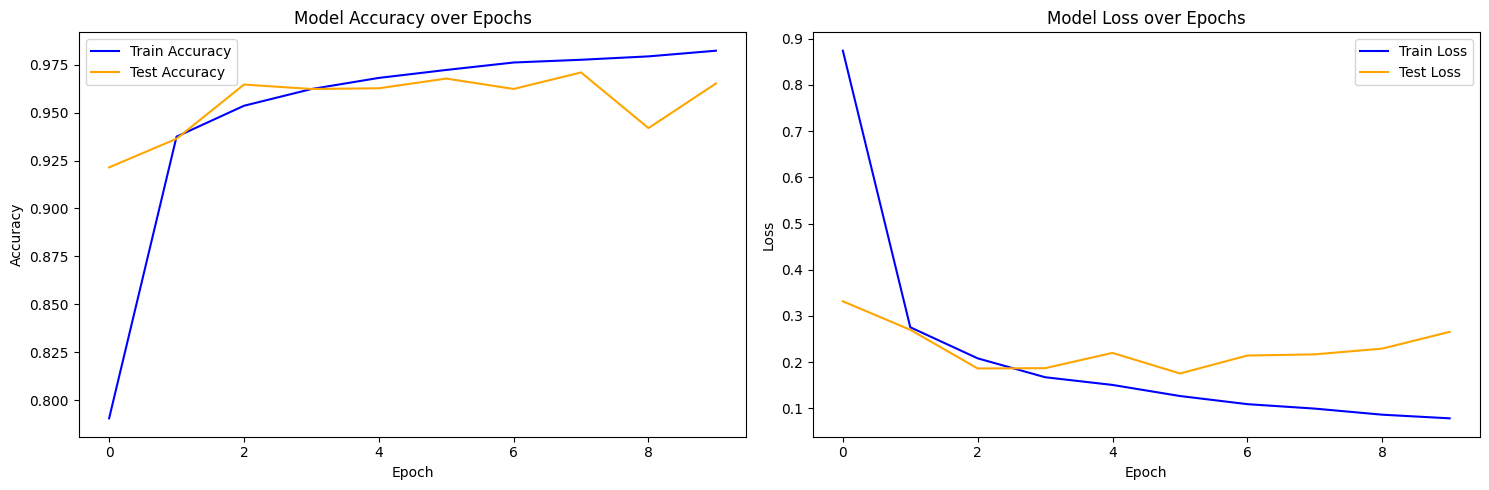


Generating Confusion Matrix...


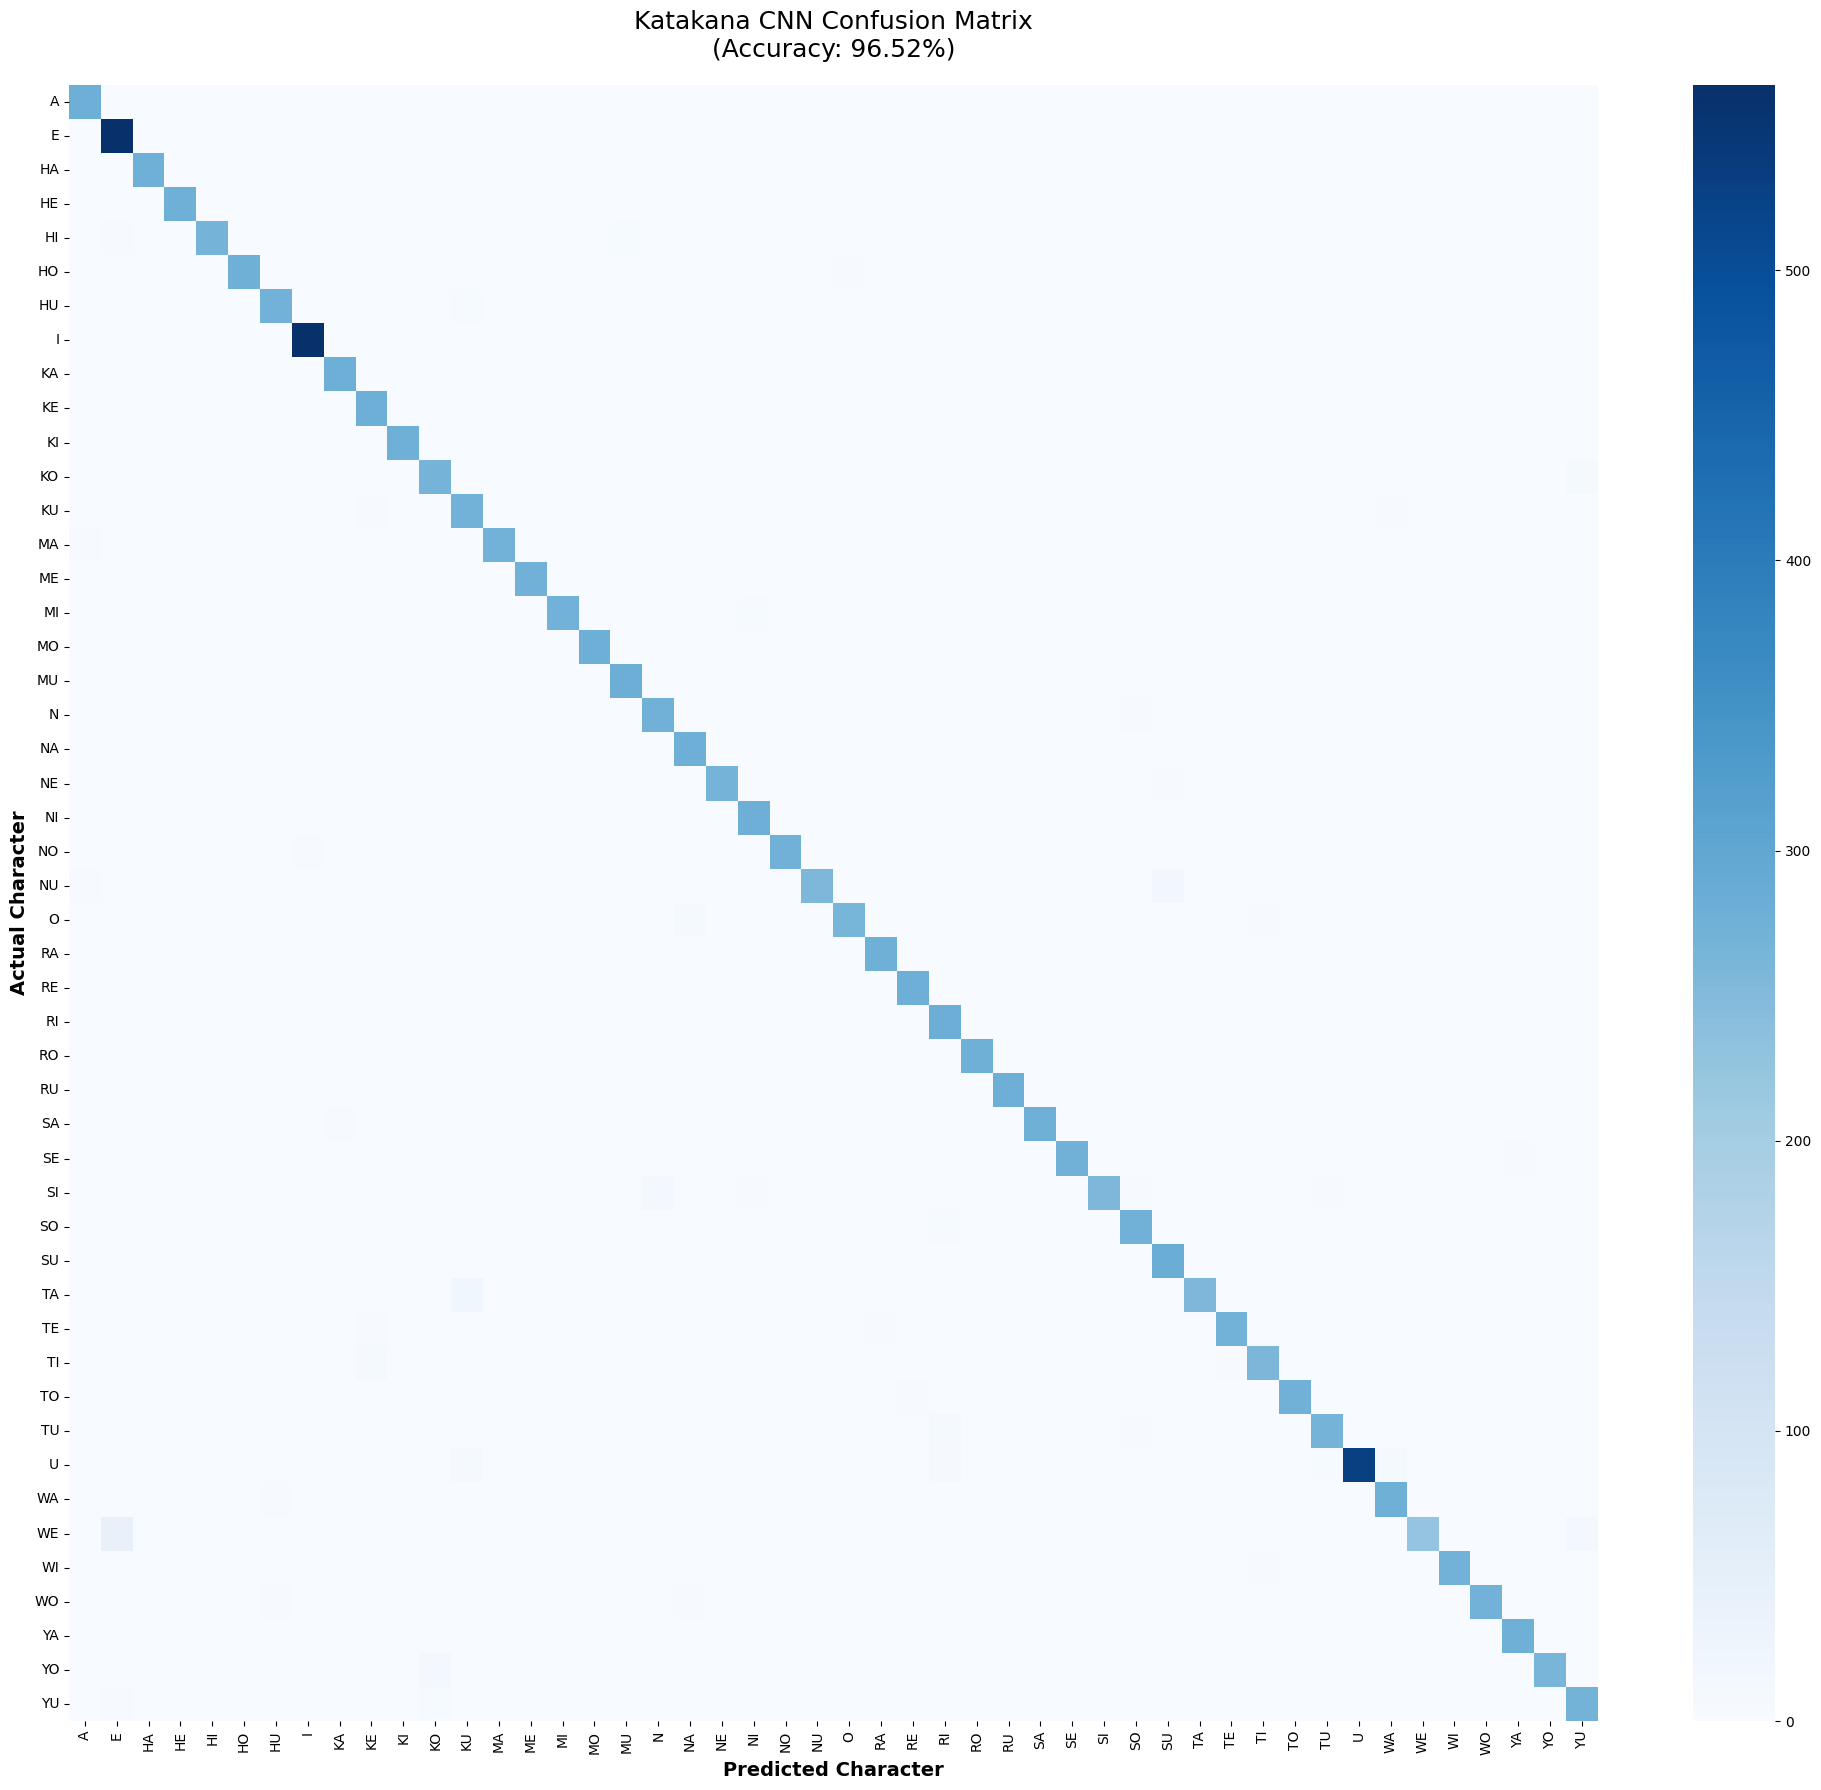

In [21]:
# Cell 8: Visualizing Results with Matplotlib
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training vs Validation Accuracy
ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Test Accuracy', color='orange')
ax[0].set_title('Model Accuracy over Epochs')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Plot 2: Training vs Validation Loss
ax[1].plot(history.history['loss'], label='Train Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Test Loss', color='orange')
ax[1].set_title('Model Loss over Epochs')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
plt.tight_layout()
plt.show()

# Plot 3: The Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.ylabel('Actual Character', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Character', fontsize=14, fontweight='bold')
plt.title(f'Katakana CNN Confusion Matrix\n(Accuracy: {accuracy * 100:.2f}%)', fontsize=18, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

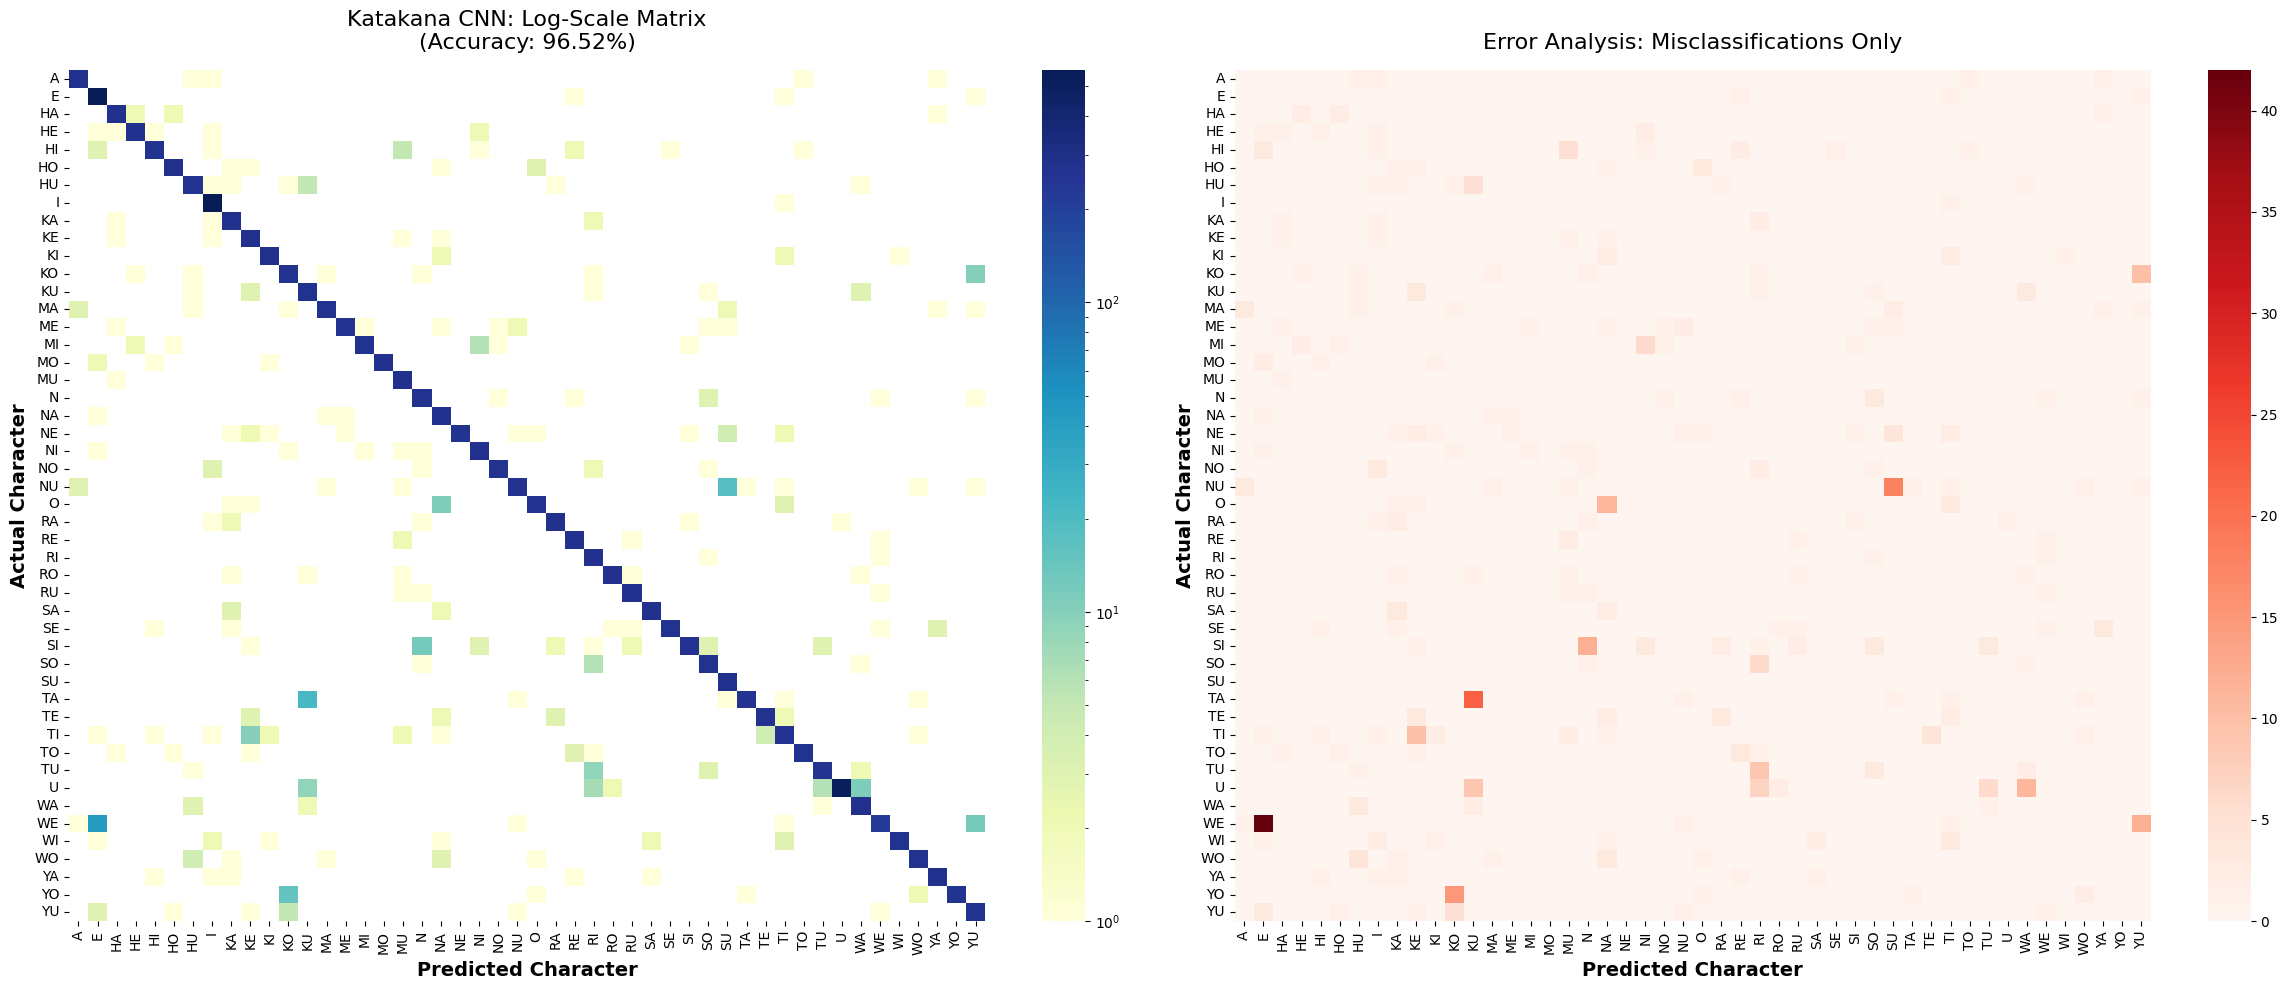

In [22]:
from matplotlib.colors import LogNorm

# Assuming you already have 'cm' (confusion matrix) and 'classes' (list of labels)
# from your previous evaluation steps.

fig, ax = plt.subplots(1, 2, figsize=(24, 10))

# ==========================================
# CHART 1: The Log-Scale Matrix
# ==========================================
# Using LogNorm() makes low numbers (like 1 or 2 errors) visually pop 
# rather than getting washed out by the high numbers (like 500 correct).

sns.heatmap(cm, annot=False, cmap='YlGnBu', 
            xticklabels=classes, yticklabels=classes, 
            norm=LogNorm(), ax=ax[0]) # <--- LogNorm is the magic trick here

ax[0].set_ylabel('Actual Character', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Predicted Character', fontsize=14, fontweight='bold')
ax[0].set_title(f'Katakana CNN: Log-Scale Matrix\n(Accuracy: {accuracy * 100:.2f}%)', fontsize=16, pad=15)
ax[0].tick_params(axis='x', rotation=90)
ax[0].tick_params(axis='y', rotation=0)

# ==========================================
# CHART 2: The "Errors Only" Matrix
# ==========================================
# We copy the matrix and fill the correct answers (the diagonal) with zeros.
# This completely isolates the model's blind spots.

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# We use a fiery color map ('Reds') because these are the mistakes!
sns.heatmap(cm_errors, annot=False, cmap='Reds', 
            xticklabels=classes, yticklabels=classes, ax=ax[1])

ax[1].set_ylabel('Actual Character', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Predicted Character', fontsize=14, fontweight='bold')
ax[1].set_title('Error Analysis: Misclassifications Only', fontsize=16, pad=15)
ax[1].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

*Section 7 Data Analytics*

In [23]:
# Cell 9: Extracting Top Misclassifications
import numpy as np

# 1. Total errors per actual character
# (Sum of the row, minus the correct predictions on the diagonal)
errors_per_class = cm.sum(axis=1) - np.diag(cm)

# Bundle the class name with its error count and sort them
class_errors = [(classes[i], errors_per_class[i]) for i in range(len(classes))]
class_errors.sort(key=lambda x: x[1], reverse=True)

print("🚨 TOP 10 MOST MISCLASSIFIED CHARACTERS (Overall) 🚨")
print("-" * 50)
for rank, (char, count) in enumerate(class_errors[:10], 1):
    print(f"#{rank}: '{char}' was predicted incorrectly {count} times.")

print("\n")

# 2. Top specific confused pairs
# We use the cm_errors matrix we made earlier (where the diagonal is 0)
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

# Flatten the matrix, sort it, and get the indices of the highest numbers
flat_indices = np.argsort(cm_errors.flatten())[::-1]

print("🔍 TOP 10 SPECIFIC CHARACTER MIX-UPS 🔍")
print("-" * 50)
found = 0
for idx in flat_indices:
    if found >= 10:
        break
        
    true_idx = idx // len(classes)
    pred_idx = idx % len(classes)
    count = cm_errors[true_idx, pred_idx]
    
    if count > 0: # Only print actual errors
        true_char = classes[true_idx]
        pred_char = classes[pred_idx]
        print(f"#{found + 1}: Actual '{true_char}' was predicted as '{pred_char}' -> {count} times.")
        found += 1

🚨 TOP 10 MOST MISCLASSIFIED CHARACTERS (Overall) 🚨
--------------------------------------------------
#1: 'WE' was predicted incorrectly 57 times.
#2: 'U' was predicted incorrectly 35 times.
#3: 'NU' was predicted incorrectly 27 times.
#4: 'SI' was predicted incorrectly 27 times.
#5: 'TA' was predicted incorrectly 26 times.
#6: 'TI' was predicted incorrectly 23 times.
#7: 'YO' was predicted incorrectly 19 times.
#8: 'O' was predicted incorrectly 16 times.
#9: 'KO' was predicted incorrectly 15 times.
#10: 'TU' was predicted incorrectly 15 times.


🔍 TOP 10 SPECIFIC CHARACTER MIX-UPS 🔍
--------------------------------------------------
#1: Actual 'WE' was predicted as 'E' -> 42 times.
#2: Actual 'TA' was predicted as 'KU' -> 22 times.
#3: Actual 'NU' was predicted as 'SU' -> 18 times.
#4: Actual 'YO' was predicted as 'KO' -> 15 times.
#5: Actual 'WE' was predicted as 'YU' -> 12 times.
#6: Actual 'SI' was predicted as 'N' -> 12 times.
#7: Actual 'U' was predicted as 'WA' -> 11 times.
#8: 

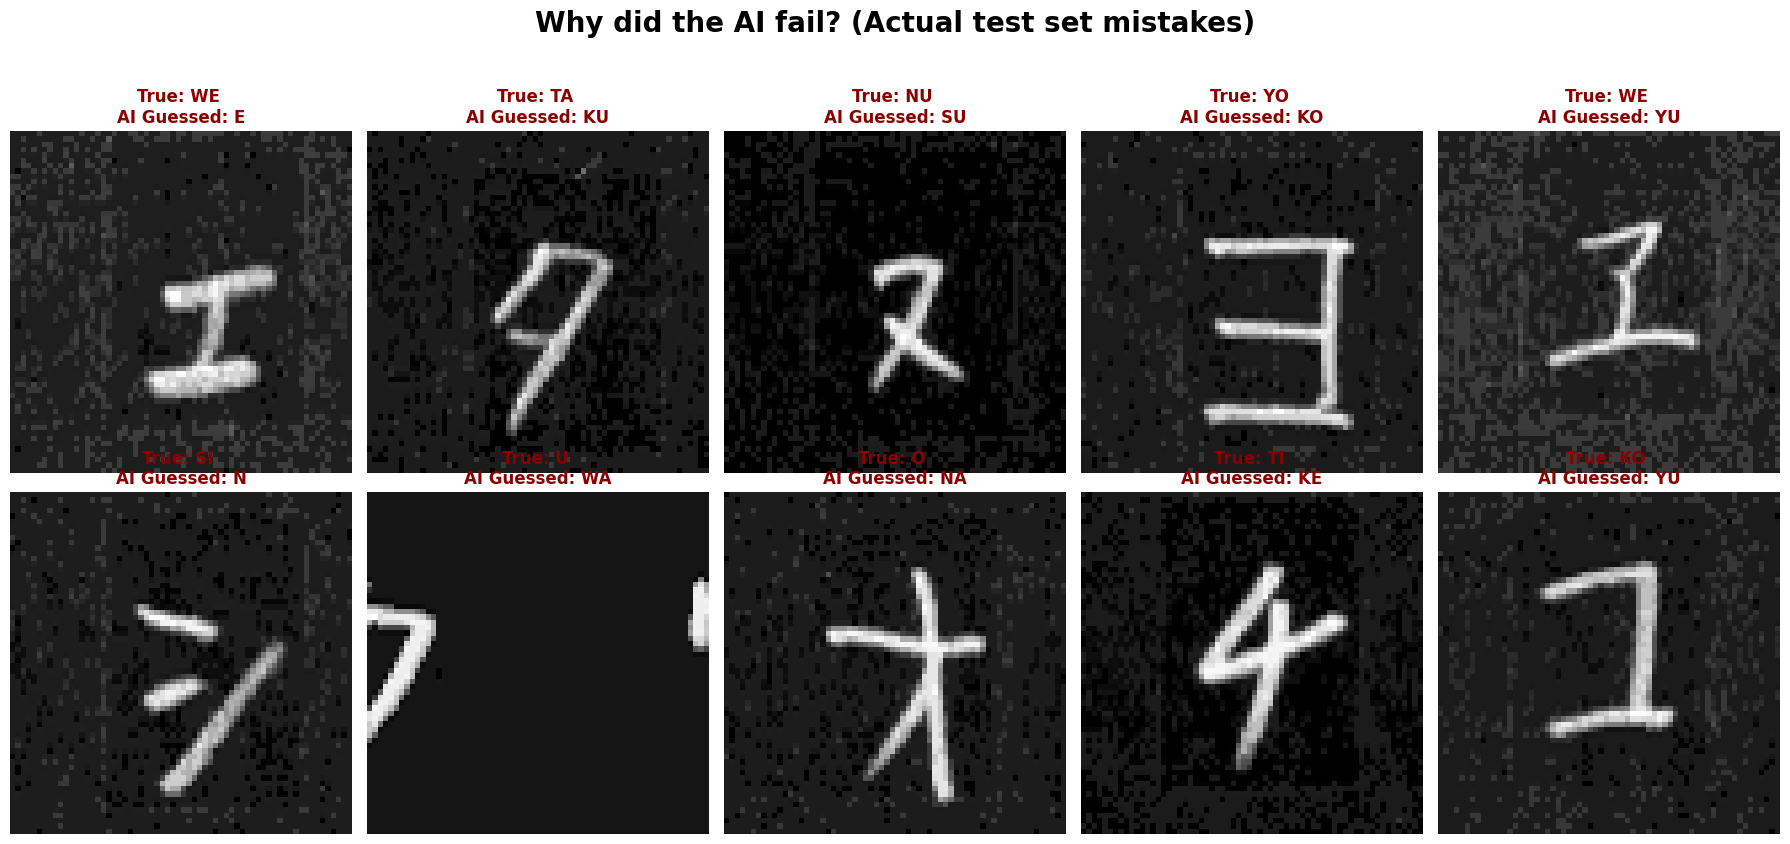

In [24]:
# Cell 10: Visualizing Specific Misclassifications
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x5 grid for the Top 10 mix-ups
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

found = 0

# We iterate through the worst errors we found in Cell 9
for idx in flat_indices:
    if found >= 10:
        break
        
    true_idx = idx // len(classes)
    pred_idx = idx % len(classes)
    
    # Check if this pair actually has errors
    if cm_errors[true_idx, pred_idx] > 0:
        
        # 1. Hunt down the exact images in the test set where this specific error occurred
        # Condition: The actual label is true_idx, BUT the AI predicted pred_idx
        mistake_indices = np.where((y_test == true_idx) & (y_pred == pred_idx))[0]
        
        if len(mistake_indices) > 0:
            # 2. Grab the first example of this mistake
            example_idx = mistake_indices[0]
            
            # Remove the color channel dimension so matplotlib can plot it (64, 64, 1) -> (64, 64)
            img = x_test[example_idx].squeeze() 
            
            true_char = classes[true_idx]
            pred_char = classes[pred_idx]
            
            # 3. Plot it
            ax = axes[found]
            ax.imshow(img, cmap='gray')
            ax.set_title(f"True: {true_char} \nAI Guessed: {pred_char}", 
                         fontsize=12, color='darkred', fontweight='bold')
            ax.axis('off')
            
            found += 1

plt.suptitle("Why did the AI fail? (Actual test set mistakes)", fontsize=20, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()